<a href="https://www.kaggle.com/code/ibrahimnibrahim/study-case-for-cognitive-performance?scriptVersionId=237484547" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Human Cognitive Performance Analysis

__Human Cognitive Performance__ : refers to the efficiency and effectiveness of mental processes involved in acquiring,</br>
processing, storing, and utilizing information. It encompasses various higher-order brain functions, including:
* __Attention__ : The ability to focus on relevant stimuli while ignoring distractions.
* __Memory__ : The capacity to encode, retain, and recall information (short-term and long-term).
* __Executive Function__ : Skills like planning, decision-making, problem-solving, and cognitive flexibility.
* __Processing Speed__ : The rate at which the brain perceives and reacts to information.
* __Learning__ : The ability to acquire and apply new knowledge or skills.
* __Perception__ : Interpreting sensory input to understand the environment


# Key Factors Affecting Cognitive Performance:
1. Age:
   * Cognitive abilities (e.g., processing speed, working memory) tend to peak in early adulthood and decline with age.
   * Neuroplasticity decreases, but skills like crystallized intelligence (knowledge) may remain stable or improve.
2. Gender:
   * Some studies suggest differences in verbal fluency (often higher in women) and spatial cognition (sometimes higher in men), but individual variability is significant.
   * Hormonal fluctuations (e.g., estrogen) may influence memory and mood.
3. Sleep Duration :
   * __Insufficient sleep__ impairs attention, memory consolidation, and decision-making.
   * __Optimal sleep__ (7–9 hours for adults) enhances learning and problem-solving.
4. Stress Level :
   * __Acute stress__ may temporarily boost focus (fight-or-flight response).
   * __Chronic stress__ damages the hippocampus (memory center) and impairs executive function.
5. Diet Type :
   * __Mediterranean or balanced diets__ (healthy fats, antioxidants) support brain health.
   * __High-sugar/processed diets__ may contribute to brain fog and inflammation.
6. Daily Screen Time :
   * __Excessive screen time__ (especially social media) can reduce attention span and disrupt sleep.
   * __Productive screen use__ (e.g., learning apps) may enhance certain cognitive skills.
7. Exercise Frequency :
   * __Regular physical activity__ boosts blood flow to the brain, improves memory, and stimulates neurogenesis.
   * __Sedentary lifestyles__ correlate with faster cognitive decline.
8. Caffeine Intake :
   * __Moderate caffeine__ (~200–400 mg/day) can enhance alertness and reaction time.
   * __Excessive intake__ leads to jitteriness, insomnia, and impaired focus.
9. Reaction Time :
    * A direct measure of processing speed and attentional control.
    * Slower reaction times may indicate fatigue, aging, or cognitive overload.
10. Memory Test Score :
    * Reflects working memory, recall ability, and learning efficiency.
    * Influenced by sleep, stress, diet, and mental exercise.

__Human Cognitive Performance__ is influenced by a wide range of *biological*, *psychological*, *environmental*, and *lifestyle*

# First look to the the Data

In [1]:
import pandas as pd

path='/kaggle/input/human-cognitive-performance-analysis/human_cognitive_performance.csv'
df=pd.read_csv(path,index_col=0)
df.head()

,Age,Gender,Sleep_Duration,Stress_Level,Diet_Type,Daily_Screen_Time,Exercise_Frequency,Caffeine_Intake,Reaction_Time,Memory_Test_Score,Cognitive_Score,AI_Predicted_Score
User_ID,,,,,,,,,,,,
U1,57,Female,6.5,3,Non-Vegetarian,6.5,Medium,41,583.33,65,36.71,39.77
U2,39,Female,7.6,9,Non-Vegetarian,10.8,High,214,368.24,58,54.35,57.68
U3,26,Male,8.2,6,Vegetarian,5.7,Low,429,445.21,49,32.57,29.54
U4,32,Male,7.8,9,Vegetarian,8.3,Low,464,286.33,94,70.15,74.59
U5,50,Male,9.7,2,Non-Vegetarian,11.3,Medium,365,237.65,62,87.54,91.78


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80000 entries, U1 to U80000
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 80000 non-null  int64  
 1   Gender              80000 non-null  object 
 2   Sleep_Duration      80000 non-null  float64
 3   Stress_Level        80000 non-null  int64  
 4   Diet_Type           80000 non-null  object 
 5   Daily_Screen_Time   80000 non-null  float64
 6   Exercise_Frequency  80000 non-null  object 
 7   Caffeine_Intake     80000 non-null  int64  
 8   Reaction_Time       80000 non-null  float64
 9   Memory_Test_Score   80000 non-null  int64  
 10  Cognitive_Score     80000 non-null  float64
 11  AI_Predicted_Score  80000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 7.9+ MB


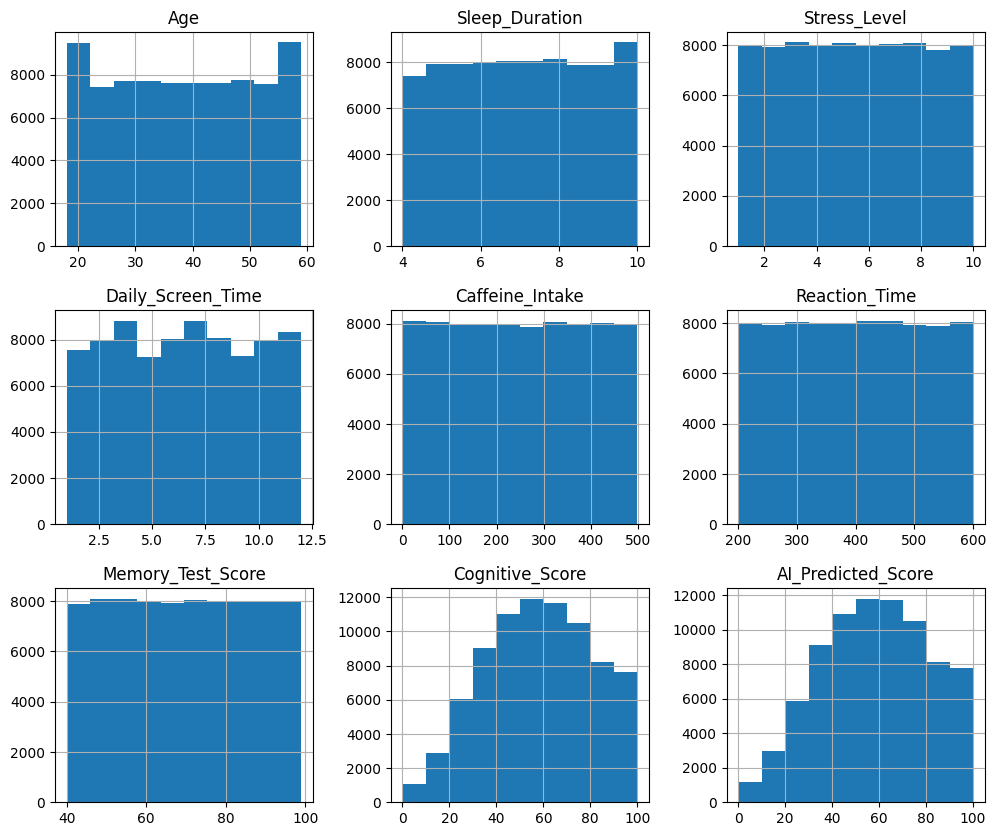

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df.hist(figsize=(12, 10))
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in ['Gender','Diet_Type','Exercise_Frequency']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

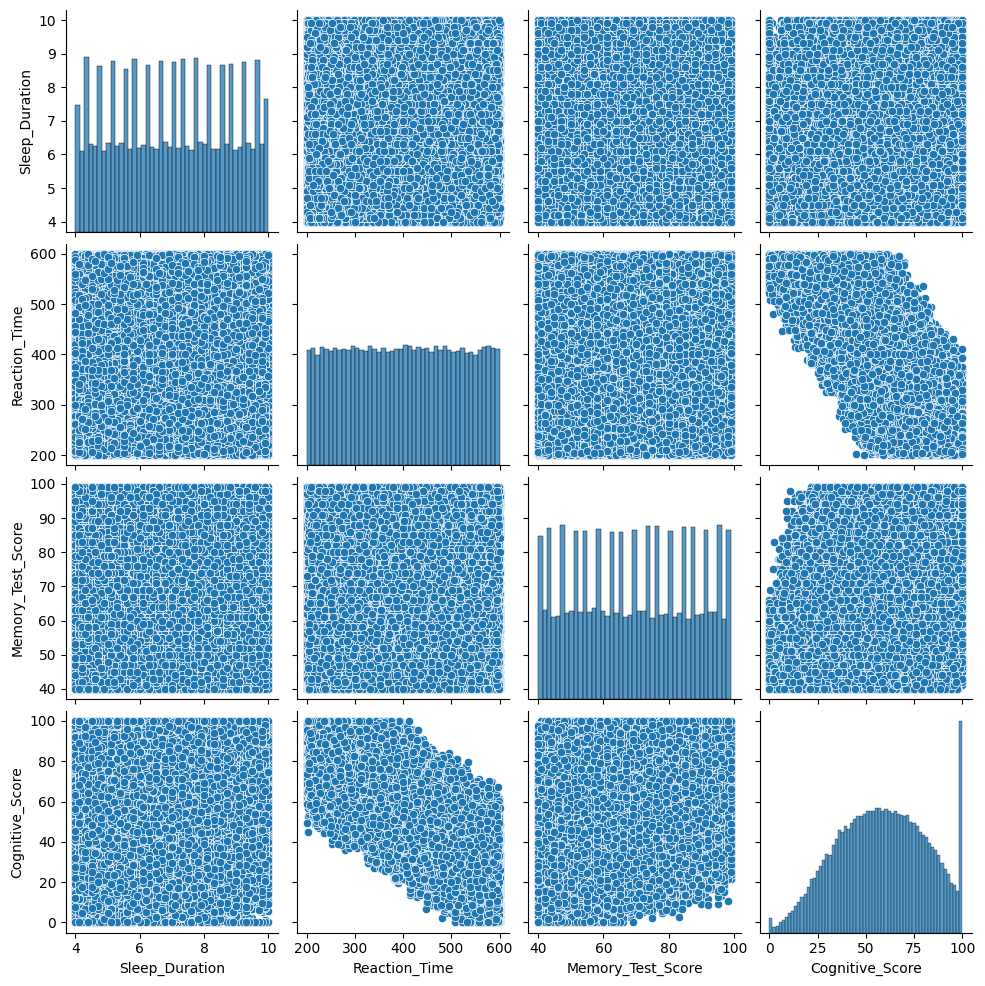

In [5]:
sns.pairplot(df[['Sleep_Duration','Reaction_Time','Memory_Test_Score','Cognitive_Score']])
plt.show()

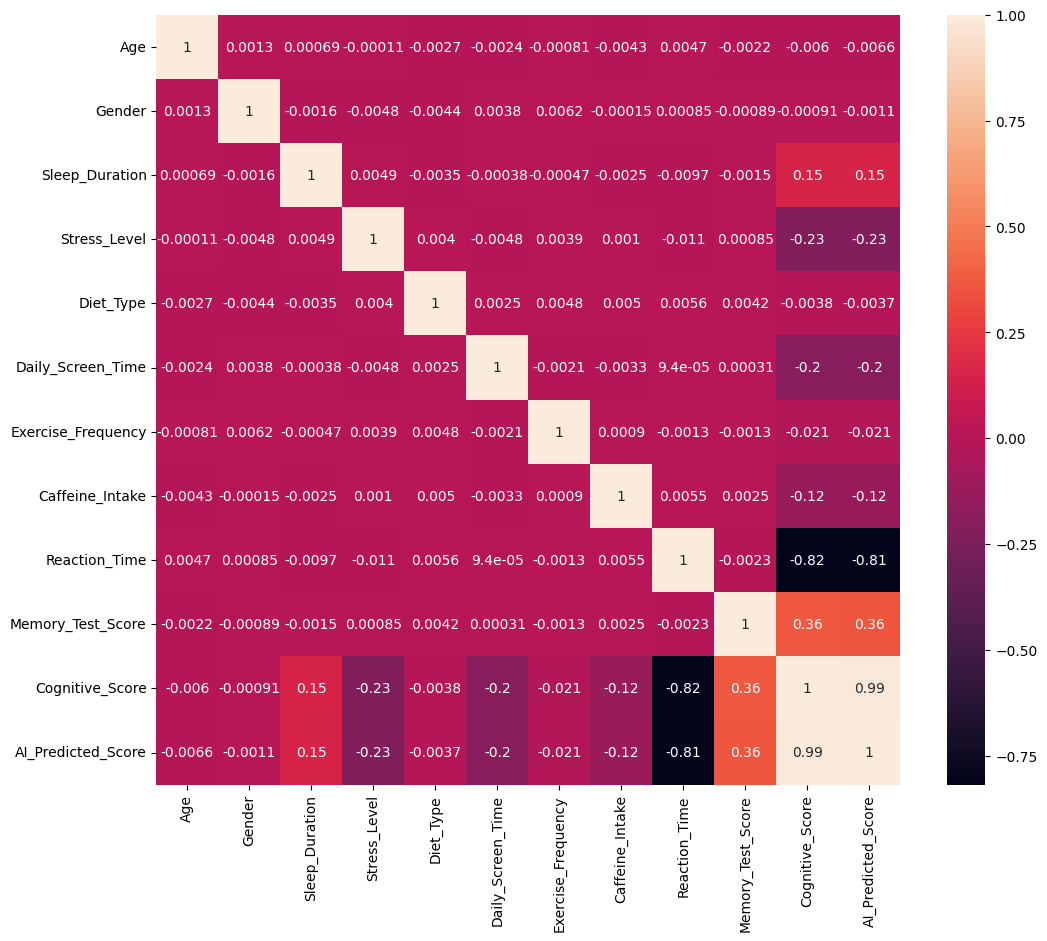

In [6]:
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True)
plt.show()

# Deep EDA

## Visualize age vs. cognitive score using scatter plots

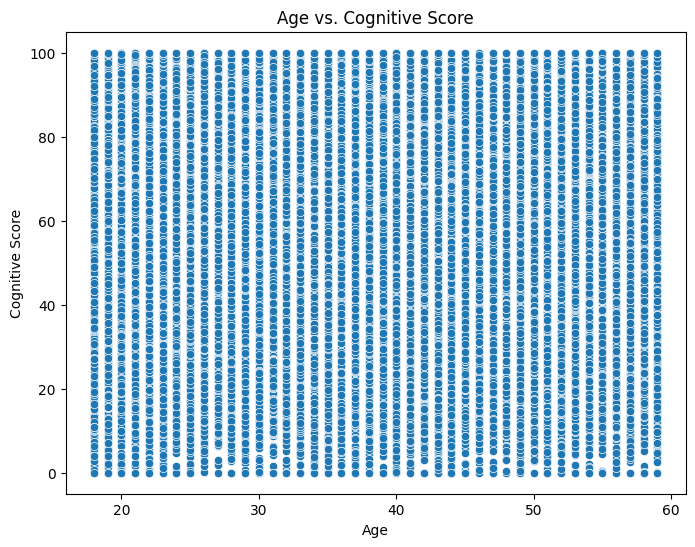

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Cognitive_Score', data=df)
plt.title('Age vs. Cognitive Score')
plt.xlabel('Age')
plt.ylabel('Cognitive Score')
plt.show()


## Analyze the impact of stress levels on cognitive performance

Correlation between Stress Level and Cognitive Performance: -0.22763851488779005

Average Cognitive Performance by Stress Level:
Stress_Level
1     66.422091
2     64.916628
3     62.363771
4     60.931377
5     59.247057
6     56.957915
7     55.322553
8     53.771490
9     51.578379
10    50.100038
Name: Cognitive_Score, dtype: float64


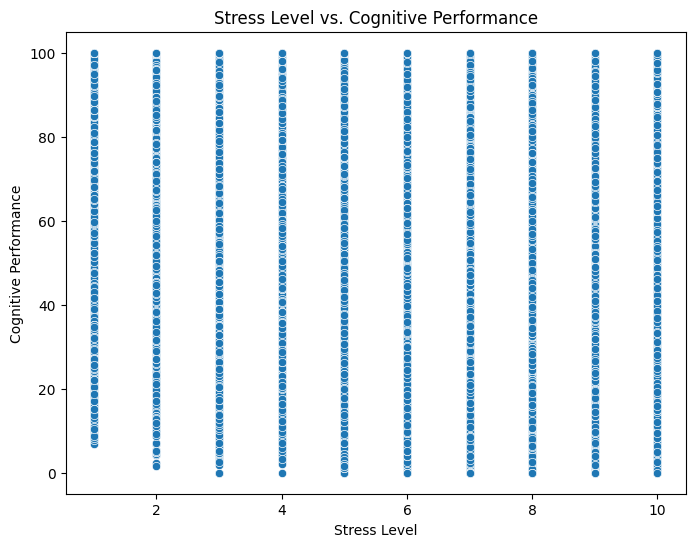

In [8]:
correlation_stress_performance = df['Stress_Level'].corr(df['Cognitive_Score'])
print(f"Correlation between Stress Level and Cognitive Performance: {correlation_stress_performance}")

# Group data by stress level and calculate the mean cognitive performance for each group.
stress_performance_groups = df.groupby('Stress_Level')['Cognitive_Score'].mean()
print("\nAverage Cognitive Performance by Stress Level:")
print(stress_performance_groups)


# Visualize the relationship using a scatter plot.
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Stress_Level', y='Cognitive_Score', data=df)
plt.title('Stress Level vs. Cognitive Performance')
plt.xlabel('Stress Level')
plt.ylabel('Cognitive Performance')
plt.show()


Linear Regression Results:
Slope: -1.831917590330863
Intercept: 68.23651503585005
R-squared: 0.05181929346031861
P-value: 0.0


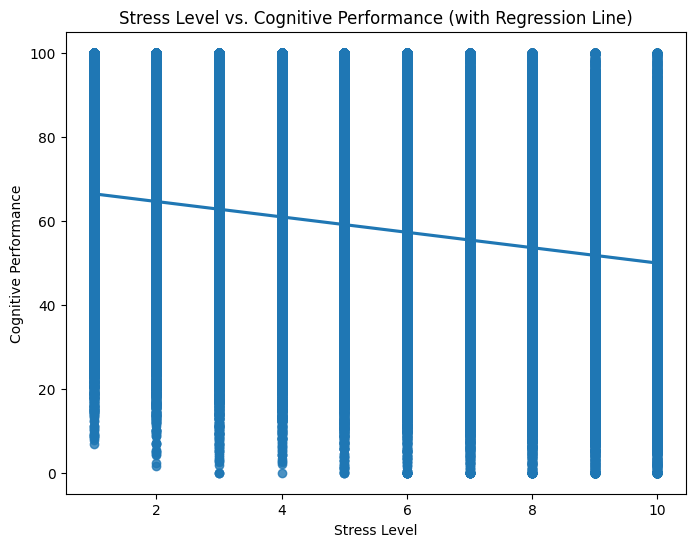

In [9]:
from scipy.stats import linregress

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(df['Stress_Level'], df['Cognitive_Score'])

# Print the regression results
print(f"\nLinear Regression Results:")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"P-value: {p_value}")

# Plot the regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='Stress_Level', y='Cognitive_Score', data=df)
plt.title('Stress Level vs. Cognitive Performance (with Regression Line)')
plt.xlabel('Stress Level')
plt.ylabel('Cognitive Performance')
plt.show()


## Study how sleep duration affects reaction time

Correlation between Sleep Duration and Reaction Time: -0.009699093430420677

Average Reaction Time by Sleep Duration:
Sleep_Duration
4.0     408.046888
4.1     399.520091
4.2     405.743555
4.3     400.565828
4.4     404.998615
           ...    
9.6     392.441883
9.7     398.036248
9.8     401.382554
9.9     400.060362
10.0    398.873662
Name: Reaction_Time, Length: 61, dtype: float64


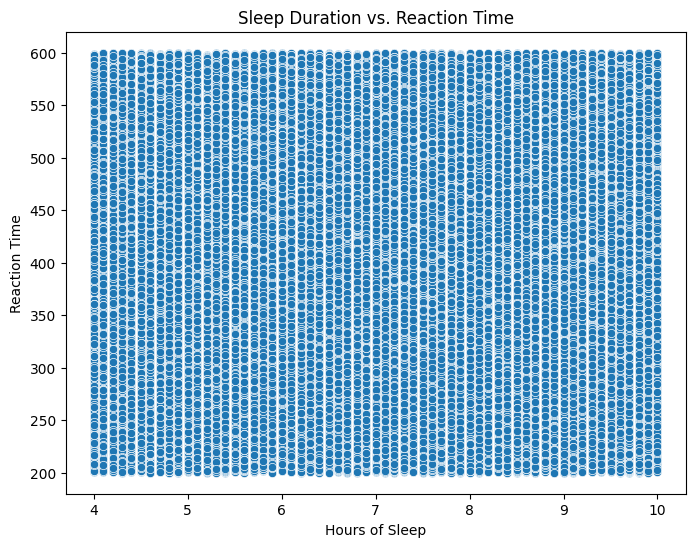

In [10]:
# Calculate the correlation between sleep duration and reaction time.
correlation_sleep_reaction = df['Sleep_Duration'].corr(df['Reaction_Time'])
print(f"Correlation between Sleep Duration and Reaction Time: {correlation_sleep_reaction}")

# Group data by sleep duration and calculate the mean reaction time for each group.
sleep_reaction_groups = df.groupby('Sleep_Duration')['Reaction_Time'].mean()
print("\nAverage Reaction Time by Sleep Duration:")
print(sleep_reaction_groups)

# Visualize the relationship using a scatter plot.
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Sleep_Duration', y='Reaction_Time', data=df)
plt.title('Sleep Duration vs. Reaction Time')
plt.xlabel('Hours of Sleep')
plt.ylabel('Reaction Time')
plt.show()


Linear Regression Results:
Slope: -0.6451541118139343
Intercept: 404.4930978169988
R-squared: 9.407241337202953e-05
P-value: 0.00608177617153877


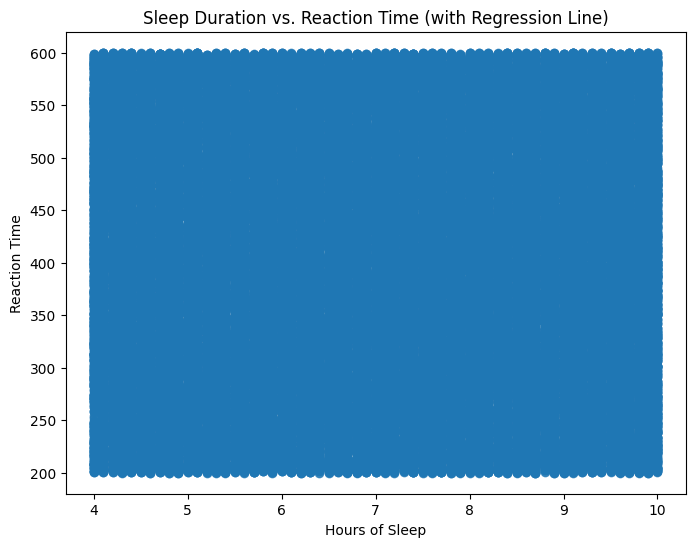

In [11]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(df['Sleep_Duration'], df['Reaction_Time'])

# Print the regression results
print(f"\nLinear Regression Results:")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"P-value: {p_value}")

# Plot the regression line
plt.figure(figsize=(8, 6))
sns.regplot(x='Sleep_Duration', y='Reaction_Time', data=df)
plt.title('Sleep Duration vs. Reaction Time (with Regression Line)')
plt.xlabel('Hours of Sleep')
plt.ylabel('Reaction Time')
plt.show()


# ML Regression

## Get Features and Labels

In [12]:
X=df.drop(['Cognitive_Score','AI_Predicted_Score'],axis=1)
y=df['Cognitive_Score']

## Features importances

In [13]:
from sklearn.ensemble import RandomForestRegressor

# Train model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# Get feature importances
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

# Display top 20 features
print(feature_importances.head(10))

              Feature  Importance
8       Reaction_Time    0.673623
9   Memory_Test_Score    0.132071
6  Exercise_Frequency    0.060060
3        Stress_Level    0.052743
5   Daily_Screen_Time    0.041161
2      Sleep_Duration    0.022139
7     Caffeine_Intake    0.015368
0                 Age    0.001912
4           Diet_Type    0.000479
1              Gender    0.000446


## Split to train and test and scale the data to with a StandardScaler

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Regression Models 

In [15]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, PassiveAggressiveRegressor
# from sklearn.svm import SVR, LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    'Random Forest': RandomForestRegressor(),
    'Extra Trees Regressor': ExtraTreesRegressor(),
    'GradientBoostingRegressor': GradientBoostingRegressor(),
    'AdaBoost Regressor': AdaBoostRegressor(),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Passive Aggressive Regressor': PassiveAggressiveRegressor(),
    # 'Support Vector Regressor': SVR(),
    # 'Linear SVR': LinearSVR(max_iter=10000),
    'K-Nearest Neighbors': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'XGB Regressor': XGBRegressor(),
}

# Train and Evaluate Models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Regression Metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'MAE': mae,
        'R²': r2
    }

# DL Regression

## NN architecture

In [16]:
import tensorflow as tf

model=tf.keras.Sequential([
    tf.keras.layers.Input((len(X.columns),)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1),
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
            loss='mse',
            metrics=['mse', 'mae'])

model.summary()

2025-05-03 01:29:19.619906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746235759.824047      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746235759.881684      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
I0000 00:00:1746235771.474923      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,929 (19.25 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

## callbacks

In [17]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_mse',  # Metric to monitor
    patience=10,         # Number of epochs with no improvement before stopping
    restore_best_weights=True  # Restores model weights from the best epoch
)

## fit the Data and test it

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=1000,  # Large number since early stopping will intervene
    batch_size=32,
    callbacks=[early_stopping],  # Add the callback here
    verbose=0
)

I0000 00:00:1746235774.496322      65 service.cc:148] XLA service 0x7abc24004b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1746235774.496848      65 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1746235774.684369      65 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1746235775.194679      65 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [19]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Regression Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results['DNN'] = {
    'MSE': mse,
    'MAE': mae,
    'R²': r2
}

2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 7.8639e-04 - mae: 0.0185 - mse: 7.8639e-04
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


# RESULTS

In [20]:
results_df = pd.DataFrame(results).T.sort_values('MSE')
results_df

,MSE,MAE,R²
DNN,0.000509,0.012924,0.999999
XGB Regressor,3.174682,1.412558,0.994023
Extra Trees Regressor,3.835469,1.526654,0.992780
GradientBoostingRegressor,4.741204,1.689104,0.991074
Random Forest,6.223112,1.978600,0.988285
K-Nearest Neighbors,23.139048,3.795776,0.956439
Decision Tree,23.576072,3.811097,0.955617
Linear Regression,35.925626,5.692621,0.932368
Ridge Regression,35.925666,5.692599,0.932368
Lasso Regression,42.166273,5.652308,0.920620


# Author:
_ENG.Ibrahim ibrahim_